# Analysis Notebook

Load saved numpy results and generate figures (no model loading).

In [1]:

import json
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "results").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent
RESULTS_ROOT = PROJECT_ROOT / "results"
FIGURES_DIR = RESULTS_ROOT / "figures"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

ARCHS = {
    "resnet50": {"methods": ["ig", "gbp", "gradcam"], "title": "ResNet-50"},
    "vit": {"methods": ["ig", "gradcam", "raw_attn", "rollout"], "title": "ViT-B/16"},
    "dinov2": {"methods": ["ig", "gradcam", "raw_attn", "rollout"], "title": "DINOv2-B"},
}


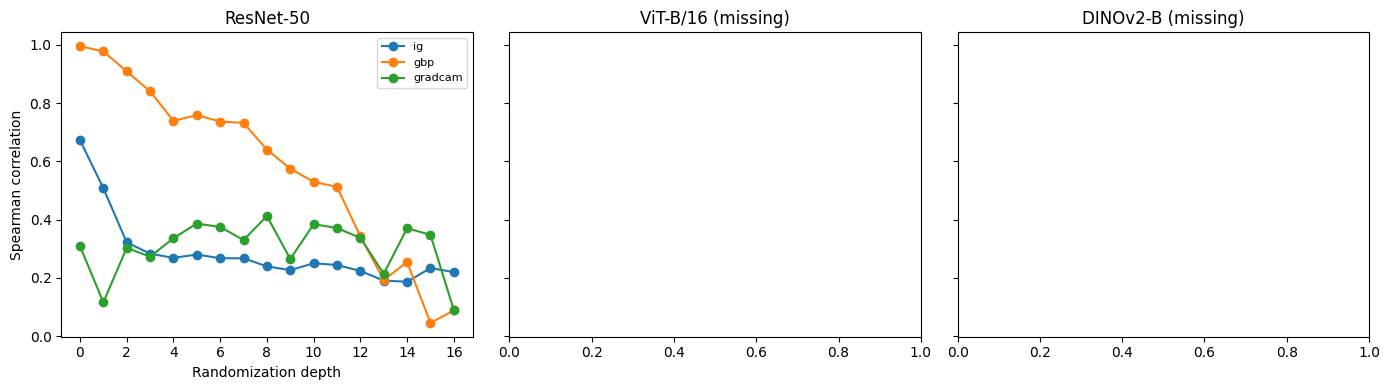

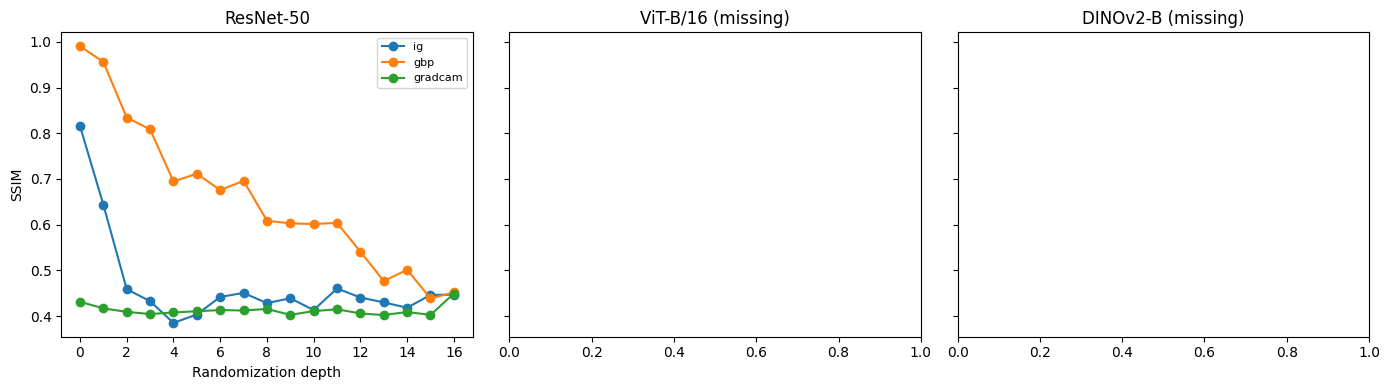

In [2]:

def plot_metric_curves(metric_suffix, ylabel, fname):
    fig, axes = plt.subplots(1, 3, figsize=(14, 4), sharey=True)
    for ax, (arch, cfg) in zip(axes, ARCHS.items()):
        d = RESULTS_ROOT / arch
        if not d.exists():
            ax.set_title(cfg["title"] + " (missing)")
            continue
        for method in cfg["methods"]:
            path = d / ("%s_%s.npy" % (method, metric_suffix))
            if not path.exists():
                continue
            vals = np.load(path)
            ax.plot(range(len(vals)), vals, marker="o", label=method)
        ax.set_xlabel("Randomization depth")
        ax.set_ylabel(ylabel)
        ax.set_title(cfg["title"])
        ax.legend(fontsize=8)
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / fname, dpi=150)
    plt.show()

plot_metric_curves("spearman_mean", "Spearman correlation", "spearman_curves.png")
plot_metric_curves("ssim_mean", "SSIM", "ssim_curves.png")


In [3]:

mech = RESULTS_ROOT / "mechanistic"
if (mech / "logit_corr_resnet.npy").exists():
    fig, ax = plt.subplots(figsize=(6, 4))
    for tag, label in [("resnet", "ResNet-50"), ("vit", "ViT-B/16")]:
        p = mech / ("logit_corr_%s.npy" % tag)
        if p.exists():
            ax.plot(np.load(p), marker="o", label=label)
    ax.set_xlabel("Randomization depth")
    ax.set_ylabel("Mean logit Pearson r")
    ax.set_title("Logit correlation under cascading randomization")
    ax.legend()
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / "logit_correlation.png", dpi=150)
    plt.show()


In [4]:

for tag in ["resnet", "vit"]:
    files = sorted(mech.glob("activation_scale_%s_depth*.npy" % tag))
    if len(files) < 2:
        continue
    a0, a1 = np.load(files[0]), np.load(files[-1])
    fig, ax = plt.subplots(figsize=(6, 4))
    ax.hist(a0, bins=50, alpha=0.5, density=True, label="depth 0")
    ax.hist(a1, bins=50, alpha=0.5, density=True, label="depth %d" % (len(files) - 1))
    ax.set_title("Activation |.| scales: %s" % tag)
    ax.legend()
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / ("activation_scales_%s.png" % tag), dpi=150)
    plt.show()


In [5]:

def plot_cascading_grid(arch, method, title):
    qual_path = RESULTS_ROOT / arch / "qual_bundle.npz"
    if not qual_path.exists():
        return
    data = np.load(qual_path, allow_pickle=True)
    key = "cascade_" + method
    if key not in data:
        return
    cascade = data[key]
    order = list(data["order"])
    nrows = len(cascade) + 2
    fig = plt.figure(figsize=(4, 0.4 * nrows))
    gs = gridspec.GridSpec(nrows, 1)
    ax = fig.add_subplot(gs[0])
    ax.imshow(data["image"])
    ax.set_title("Input")
    ax.axis("off")
    ax = fig.add_subplot(gs[1])
    ax.imshow(data["baseline_" + method], cmap="gray")
    ax.set_title("Baseline (no randomization)")
    ax.axis("off")
    for i, m in enumerate(cascade):
        ax = fig.add_subplot(gs[i + 2])
        ax.imshow(m, cmap="gray")
        ax.set_title("Depth %d: %s" % (i, order[i] if i < len(order) else ""))
        ax.axis("off")
    fig.suptitle(title)
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / ("cascade_%s_%s.png" % (arch, method)), dpi=150)
    plt.show()

plot_cascading_grid("resnet50", "gbp", "ResNet-50 GBP (Adebayo replication check)")
plot_cascading_grid("resnet50", "ig", "ResNet-50 IG")
plot_cascading_grid("vit", "raw_attn", "ViT raw attention")
plot_cascading_grid("dinov2", "rollout", "DINOv2 rollout")
print("Figures saved to", FIGURES_DIR)


Figures saved to /Users/alexatran/saliency_and_attention/results/figures
